# 16. Peak mCG motif

Part of the **[Fig. 2 chapter](fig2.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{indir}merged_allc/subtype_globalCG.csv.gz'`  ·  _sc/pseudobulk mC (allc)_
- `f'{peakdir}peak_majortype_CGN.mcds'`  ·  _mC matrix (mcds)_
- `f'{peakdir}{ct}.bed'`  ·  _other_
- `f'{REF_ROOT}/aertslab_motif_colleciton/v10nr_clust_public/snapshots/motifs-v10-nr.hgnc-m0.00001-o0.0.tbl'`  ·  _reference_
- `f'{REF_ROOT}/aertslab_motif_colleciton/motifs.txt'`  ·  _reference_
- `f'{REF_ROOT}/yin_2017_motif_type.csv'`  ·  _reference_
- `f'{outdir}HOCOMOCOv11_core_motif_list.txt'`  ·  _other_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

[repro_guard] active — READ-ONLY (all writes skipped; inline figures still render)


In [2]:
# [pipeline/shell command — commented out; output is cached on disk]
# cd /large_storage/zhoulab/zhoujt/project/ENTEx/scATAC/peak/majortype/
# allcools generate-dataset --allc_table /large_storage/zhoulab/zhoujt/project/ENTEx/merged_allc/L1/CGN/allclist_majortype.tsv \
# --output_path peak_majortype_CGN.mcds \
# --chrom_size_path /large_storage/zhoulab/ref/hg38/fasta/hg38.main.chrom.sizes \
# --obs_dim majortype \
# --cpu 32 \
# --chunk_size 1 \
# --regions peak concat_peak.bed \
# --quantifiers peak count CGN



In [3]:
import os
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import zscore
from concurrent.futures import ProcessPoolExecutor, as_completed

import anndata
from ALLCools.mcds import MCDS, RegionDS
from ALLCools.clustering import *
from ALLCools.plot import *

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [4]:
indir = f'{ENTEX_ROOT}/'
peakdir = f'{indir}scATAC/peak/majortype/'
outdir = f'{indir}analysis/mCG_peak_motif/'


In [5]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
# L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_meta = L1_meta.drop(['c7'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [6]:
import cooler
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [7]:
global_mc = pd.read_csv(f'{indir}merged_allc/subtype_globalCG.csv.gz', index_col=0, header=0)
global_mc['L1'] = global_mc.index.str.split('-').str[0]
global_mc.loc[global_mc['L1']=='c7', 'L1'] = 'c35'
global_mc.loc['c7-b1', 'L1'] = 'c36'
global_mc = global_mc.groupby('L1').sum()
global_mc['ratio'] = global_mc['mc'] / global_mc['cov']


In [8]:
mcds = MCDS.open(f'{peakdir}peak_majortype_CGN.mcds', obs_dim='majortype', var_dim='peak')
mcds


<xarray.MCDS> Size: 305MB
Dimensions:     (count_type: 2, majortype: 37, peak: 810407)
Coordinates:
  * count_type  (count_type) <U3 24B 'mc' 'cov'
  * majortype   (majortype) <U3 444B 'c0' 'c10' 'c11' 'c12' ... 'c7' 'c8' 'c9'
    mc_type     <U3 12B 'CGN'
  * peak        (peak) <U11 36MB 'peak_0' 'peak_1' ... 'peak_810406'
    peak_chrom  (peak) <U5 16MB ...
    peak_end    (peak) int64 6MB ...
    peak_start  (peak) int64 6MB ...
Data variables:
    peak_da     (majortype, peak, count_type) uint32 240MB dask.array<chunksize=(1, 101301, 1), meta=np.ndarray>
Attributes:
    obs_dim:  majortype
    var_dim:  peak

In [9]:
mcds.add_mc_frac(normalize_per_cell=False)


In [10]:
data_all = mcds['peak_da_frac'].to_pandas().drop(['c7'], axis=0)
data_all


peak,peak_0,peak_1,peak_2,peak_3,peak_4,peak_5,peak_6,peak_7,peak_8,peak_9,...,peak_810397,peak_810398,peak_810399,peak_810400,peak_810401,peak_810402,peak_810403,peak_810404,peak_810405,peak_810406
majortype,,,,,,,,,,,,,,,,,,,,,
c0,0.721878,0.012066,0.927741,0.441268,0.824356,0.099239,0.940387,0.861528,0.161527,0.834783,...,0.198782,0.946250,0.860211,0.356655,0.900283,0.717487,0.005798,0.325634,0.819669,0.609598
c10,0.720289,0.014993,0.767153,0.862450,0.722288,0.120499,0.968925,0.913555,0.329666,0.953753,...,0.215578,0.916857,0.776934,0.476920,0.955253,0.973866,0.011341,0.939117,0.703436,0.667502
c11,0.616812,0.008934,0.691791,0.764476,0.753512,0.132541,0.930215,0.543107,0.159578,0.786943,...,0.214941,0.898488,0.391658,0.319456,0.875208,0.826278,0.004790,0.838061,0.747760,0.573518
c12,0.649349,0.010786,0.533311,0.649349,0.770333,0.175376,0.916179,0.565455,0.146361,0.879835,...,0.229113,0.888026,0.325291,0.477338,0.925363,0.874014,0.005321,0.819604,0.762966,0.597441
c13,0.677904,0.001820,0.580796,0.809536,0.694442,0.560645,0.921943,0.645880,0.169954,0.706603,...,0.226356,0.911084,0.752531,0.193034,0.867107,0.889902,0.002866,0.919294,0.708504,0.583346
c14,0.701491,0.024971,0.829195,0.842713,0.746737,0.096377,0.954313,0.037912,0.094894,0.843129,...,0.186622,0.933621,0.087248,0.291395,0.953284,0.946401,0.009422,0.850337,0.744309,0.652296
c15,0.782547,0.009901,0.934132,0.782547,0.836277,0.262739,0.966649,0.910088,0.112906,0.987874,...,0.118891,0.951685,0.873403,0.585824,0.974393,0.950432,0.008211,0.912147,0.857590,0.599438
c16,0.799177,0.035932,0.881328,0.799177,0.731389,0.341682,0.963934,0.286915,0.371992,0.819240,...,0.207792,0.948047,0.465108,0.686621,0.974885,0.967749,0.012809,0.940316,0.702263,0.666873
c17,0.635298,0.011147,0.616916,0.635298,0.738479,0.076835,0.897127,0.831230,0.076869,0.694473,...,0.234532,0.905615,0.539251,0.510730,0.749169,0.872659,0.006487,0.858353,0.744132,0.651685


In [11]:
peak = mcds[['peak_chrom', 'peak_start', 'peak_end']].to_pandas().drop(['mc_type'], axis=1)
peak.columns = ['chrom', 'start', 'end']
peak

,chrom,start,end
peak,,,
peak_0,chr1,9955,10355
peak_1,chr1,29163,29563
peak_2,chr1,79215,79615
peak_3,chr1,180580,180980
peak_4,chr1,181273,181673
...,...,...,...
peak_810402,chr22,50780226,50780626
peak_810403,chr22,50783437,50783837
peak_810404,chr22,50785276,50785676


In [12]:
hypo = (data_all<(global_mc.loc[data_all.index, ['ratio']].values-0.3))
hyper = (data_all>(global_mc.loc[data_all.index, ['ratio']].values+0.1))
print((hypo.sum(axis=0)>0).sum(), (hyper.sum(axis=0)>0).sum())


639681 660656


In [14]:
peak = peak.reset_index()
peak.index = peak['chrom'].astype(str) + ':' + peak['start'].astype(str) + '-' + peak['end'].astype(str)


In [15]:
peak_all = []
for ct in L1_meta.index:
    if not os.path.isfile(f'{peakdir}{ct}.bed'):
        continue
    peak_tmp = pd.read_csv(f'{peakdir}{ct}.bed', sep='\t', header=None, index_col=None)
    peak_tmp.columns = ['chrom', 'start', 'end']
    peak_tmp.index = peak_tmp['chrom'].astype(str) + ':' + peak_tmp['start'].astype(str) + '-' + peak_tmp['end'].astype(str)
    peak_tmp['mCG'] = data_all.loc[ct, peak.loc[peak_tmp.index, 'peak'].values].values
    peak_tmp['majortype'] = ct
    peak_all.append(peak_tmp)
    print(ct)
    

c33


c3
c22


c9


c20
c25


c30


...

c15


c26
c5


c10
c16


c21


c12


In [16]:
peak_all = pd.concat(peak_all, axis=0)
peak_mid = peak_all.groupby('majortype')['mCG'].median()
peak_ave = peak_all.groupby('majortype')['mCG'].mean()


In [17]:
# leg_order = peak_ave.sort_values().index
leg_order = global_mc['ratio'].sort_values().index
leg_order = leg_order[leg_order.isin(peak_all['majortype'])]


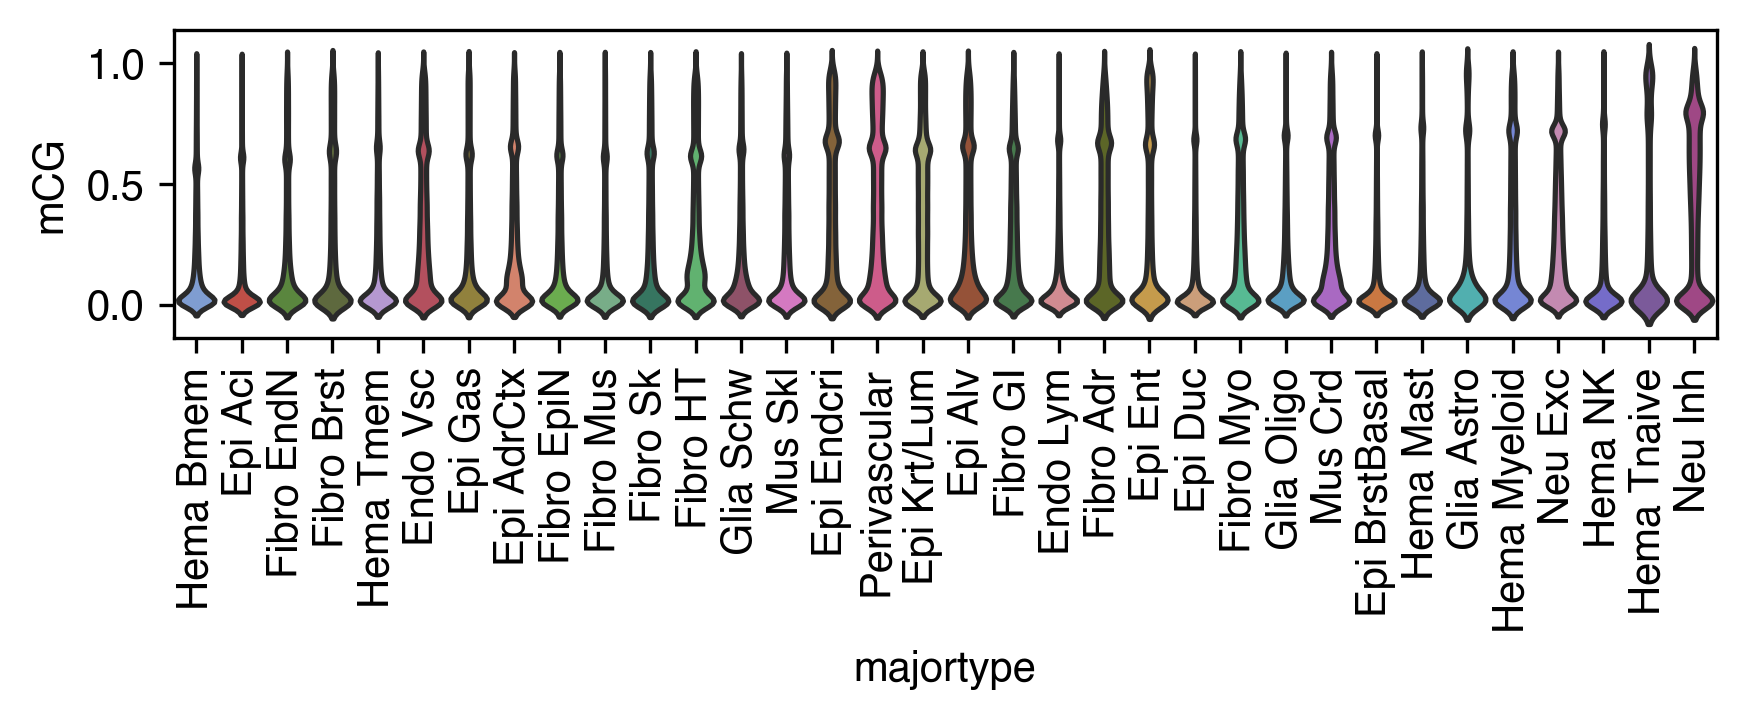

In [18]:
fig, ax = plt.subplots(figsize=(6, 2.5), dpi=300)
sns.violinplot(peak_all, x='majortype', y='mCG', palette=L1_color, 
               order=leg_order, ax=ax, inner=None)
ax.set_xticks(np.arange(len(leg_order)))
ax.set_xticklabels(leg_order.map(L1_annot), rotation=90)
fig.tight_layout()
fig.savefig(f'{outdir}peak_mCG_violin.pdf', transparent=True)


In [19]:
mid = (peak_all['start'] + peak_all['end']) // 2
peak_all['start'] = mid - 500
peak_all['end'] = mid + 500
peak_all = peak_all.loc[(peak_all['start']>0) & (peak_all['end']<peak_all['chrom'].map(chrom_sizes))]


In [20]:
for ct,peak_tmp in peak_all.groupby('majortype'):
    os.makedirs(f'{outdir}{ct}/bed/hypo/', exist_ok=True)
    os.makedirs(f'{outdir}{ct}/bed/hyper/', exist_ok=True)
    peak_hypo = peak_tmp.loc[peak_tmp['mCG']<0.1]
    peak_hyper = peak_tmp.loc[peak_tmp['mCG']>(global_mc.loc[ct, 'ratio']+0.1)]
    peak_hypo[['chrom', 'start', 'end']].to_csv(f'{outdir}{ct}/bed/hypo/{ct}.bed', sep='\t', header=False, index=False)
    peak_hyper[['chrom', 'start', 'end']].to_csv(f'{outdir}{ct}/bed/hyper/{ct}.bed', sep='\t', header=False, index=False)
    print(ct, peak_hypo.shape[0], peak_hyper.shape[0])
    

c0 54510 5433
c1 37272 1484
c10 50126 2104
c11 51813 10084
c12 54025 22420
c13 61274 18933
c14 48352 830
c15 29700 5426
c16 28422 2796
c17 58263 10039
c18 52962 12061
c19 54558 5121
c20 65804 12069
c21 49237 2213
c22 58293 1337
c23 62225 5648
c24 38409 579
c25 64200 776
c26 52532 4033
c27 30098 387
c28 63342 4401
c29 41882 5592
c3 49599 10531
c30 51123 497
c31 34659 2816
c32 40420 1280
c33 46781 687
c34 47246 3617
c35 41992 1750
c4 71641 7507
c5 50589 2625
c6 51476 3414
c8 77562 19141
c9 46239 5242


In [21]:
# [pipeline/shell command — commented out; output is cached on disk]
# ## summit/loop ATAC peak enriched motif

# for i in `seq 1 35`; do (
# ct=c${i}
# dbdir=/large_storage/zhoulab/zhoujt/project/ENTEx/analysis/loop_peak_motif
# outdir=/large_storage/zhoulab/zhoujt/project/ENTEx/analysis/mCG_peak_motif
# if test -e "${outdir}/${ct}/bed/hypo/${ct}.bed"; then 
# scenicplus grn_inference motif_enrichment_cistarget \
#     --region_set_folder ${outdir}/${ct}/bed \
#     --cistarget_db_fname ${dbdir}/${ct}/merge_peak.regions_vs_motifs.rankings.feather \
#     --output_fname_cistarget_result ${outdir}/${ct}/ctx_results.hdf5 \
#     --temp_dir ${outdir}/${ct}/tmp \
#     --species "homo_sapiens" \
#     --fr_overlap_w_ctx_db 0.9 \
#     --auc_threshold 0.005 \
#     --nes_threshold 3.0 \
#     --rank_threshold 0.05 \
#     --path_to_motif_annotations f"{REF_ROOT}/aertslab_motif_colleciton/v10nr_clust_public/snapshots/motifs-v10-nr.hgnc-m0.00001-o0.0.tbl" \
#     --annotation_version "v10nr_clust" \
#     --motif_similarity_fdr 0.001 \
#     --orthologous_identity_threshold 0.0 \
#     --annotations_to_use "Direct_annot Orthology_annot" \
#     --write_html \
#     --output_fname_cistarget_html ${outdir}/${ct}/ctx_results.html \
#     --n_cpu 32
# fi
# )
# done



In [22]:
motif = pd.read_csv(f'{REF_ROOT}/aertslab_motif_colleciton/v10nr_clust_public/snapshots/motifs-v10-nr.hgnc-m0.00001-o0.0.tbl', sep='\t', header=0, index_col=0)
motif

,motif_name,motif_description,source_name,source_version,gene_name,motif_similarity_qvalue,similar_motif_id,similar_motif_description,orthologous_identity,orthologous_gene_name,orthologous_species,description
#motif_id,,,,,,,,,,,,
metacluster_196.3,EcR_usp,EcR/usp,bergman,1.1,HNF4A,0.000000e+00,NaN,NaN,0.270042,FBgn0003964,D. melanogaster,gene is orthologous to FBgn0003964 in D. melan...
metacluster_196.3,EcR_usp,EcR/usp,bergman,1.1,HNF4G,0.000000e+00,NaN,NaN,0.276923,FBgn0003964,D. melanogaster,gene is orthologous to FBgn0003964 in D. melan...
metacluster_196.3,EcR_usp,EcR/usp,bergman,1.1,NR1D1,0.000000e+00,NaN,NaN,0.157980,FBgn0000546,D. melanogaster,gene is orthologous to FBgn0000546 in D. melan...
metacluster_196.3,EcR_usp,EcR/usp,bergman,1.1,NR1D2,0.000000e+00,NaN,NaN,0.170984,FBgn0000546,D. melanogaster,gene is orthologous to FBgn0000546 in D. melan...
metacluster_196.3,EcR_usp,EcR/usp,bergman,1.1,NR1H2,0.000000e+00,NaN,NaN,0.317391,FBgn0000546,D. melanogaster,gene is orthologous to FBgn0000546 in D. melan...
...,...,...,...,...,...,...,...,...,...,...,...,...
metacluster_179.4,YPL089C_419,YPL089C_419,yetfasco,1.02,MEF2A,4.378370e-06,metacluster_179.4,BORCS8-MEF2B[gene ID: ENSG00000064489 species:...,1.000000,NaN,NaN,motif similar to cisbp__M08212 ('BORCS8-MEF2B[...
metacluster_145.8,YPR052C_879,YPR052C_879,yetfasco,1.02,HOXB7,1.918920e-06,cisbp__M00332,HOXB7[gene ID: ENSG00000260027 species: Homo s...,1.000000,NaN,NaN,motif similar to cisbp__M00332 ('HOXB7[gene ID...
metacluster_145.8,YPR052C_879,YPR052C_879,yetfasco,1.02,TBP,7.388670e-08,metacluster_145.8,V$TBP_06: Tbp,0.911504,ENSMUSG00000014767,M. musculus,gene is orthologous to ENSMUSG00000014767 in M...


In [23]:
# [pipeline/shell command — commented out; output is cached on disk]
# /large_storage/zhoulab/ref/motif_databases/JASPAR/JASPAR2024_CORE_non-redundant_pfms.meme



In [24]:
motif = motif.loc[motif['description'].str.split(' ').str[0]=='gene']
motif.shape

(129066, 12)

In [25]:
motif_list = pd.read_csv(f'{REF_ROOT}/aertslab_motif_colleciton/motifs.txt', index_col=0, header=None).index
motif_list = motif_list.str.replace('.cb','')


In [26]:
motif_list.isin(motif.index).sum()

4219

In [27]:
motif = motif.loc[motif.index.isin(motif_list)]
print(motif.shape)

(73372, 12)


In [28]:
motif.loc[(motif['gene_name']=='CTCF') & (motif['description']=='gene is directly annotated')].index.unique()

Index(['metacluster_159.3', 'metacluster_132.2', 'metacluster_101.6',
       'metacluster_101.5', 'metacluster_126.7',
       'kznf__CTCF_Rhee2011.2_ChIP-exo', 'kznf__CTCF_Rhee2011.3_ChIP-exo',
       'kznf__CTCF_Transfac.4_Transfac', 'kznf__CTCF_Transfac.5_Transfac',
       'kznf__CTCF_Transfac.6_Transfac', 'kznf__CTCF_Transfac.7_Transfac',
       'kznf__CTCF_Transfac.8_Transfac'],
      dtype='object', name='#motif_id')

In [29]:
#tf2call['Call'].unique()
callmap = {'MethylPlus':'MethylPlus', 
           'MethylMinus':'MethylMinus', 
           'Little effect and MethylMinus':'MethylMinus',
           'MethylMinus and MethylPlus':'no info', 
           'Little effect and MethylPlus':'MethylPlus',
           'MethylPlus and Little effect':'MethylPlus', 
           'MethylMinus and Little effect':'MethylMinus',
           'MethylPlus and MethylMinus':'no info', 
           'Little effect':'Little effect', 
           'inconclusive':'no info'
          }

In [30]:
motif_mc_annot = pd.read_csv(f'{REF_ROOT}/yin_2017_motif_type.csv', header=0, index_col=0)
motif_mc_annot = motif_mc_annot.loc[~motif_mc_annot.index.isna()]
motif_mc_annot['Call'] = motif_mc_annot['Call'].map(callmap)
motif_mc_annot = motif_mc_annot.loc[motif_mc_annot.index.isin(motif['gene_name'])]
motif_mc_annot

,clone type,Call,methyl-SELEX call,bisulfite call,comment,seed used for bisulfite SELEX,start position of CG,enrichment of mCG,CG frequency,TG frequency,CG frequency.1,TG frequency.1,CG frequency.2,TG frequency.2,CG frequency.3,TG frequency.3
TF name,,,,,,,,,,,,,,,,
ALX3,eDBD,MethylPlus,MethylPlus,low complexity motif,low complexity motif,TTAAYGAW,5.0,50.00%,0.10,0.07,0.04,0.19,0.11,0.07,0.06,0.16
CDX4,FL,MethylPlus,MethylPlus,MethylPlus,concordant,NGTYGTAAAWN,4.0,59.23%,0.45,0.03,0.13,0.26,0.52,0.02,0.23,0.17
CDX4,eDBD,MethylPlus,MethylPlus,MethylPlus,concordant,NGTYGTAAAAN,4.0,164.71%,0.27,0.02,0.04,0.16,0.31,0.02,0.12,0.10
CEBPB,eDBD,MethylPlus,Little effect,weak MethylPlus,effect revealed by bisulfite,NRTTGYGYAAYN,6.0,14.83%,0.54,0.10,0.29,0.44,0.61,0.09,0.37,0.41
CEBPE,eDBD,MethylPlus,Little effect,weak MethylPlus,effect revealed by bisulfite,NRTTGYGYAAYN,6.0,12.01%,0.60,0.07,0.31,0.41,0.71,0.06,0.40,0.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF177,eDBD,no info,MethylMinus,weak MethylPlus,inconclusive direction,NTYGRTYKNNNNNNNNAGTYATN,3.0,15.71%,0.19,0.32,0.07,0.51,0.20,0.32,0.09,0.53
ZNF597,FL,no info,MethylMinus and MethylPlus,MethylPlus,inconclusive direction,GGYBGYYATYTTGN,3.0,115.76%,0.44,0.02,0.11,0.36,0.50,0.01,0.28,0.28
ZNF76,eDBD,no info,MethylMinus,weak MethylMinus,inconclusive direction,NWYYYAYAATGYANYGYGN,15.0,-10.26%,0.30,0.34,0.16,0.62,0.27,0.40,0.13,0.67


In [31]:
motif_mc_dict = pd.Series('no info', index=motif['gene_name'].unique())
motif_mc_dict.loc[motif_mc_annot.index] = motif_mc_annot['Call'].copy()
motif_mc_dict.value_counts()

no info          1136
MethylPlus        146
MethylMinus        92
Little effect      21
Name: count, dtype: int64

In [32]:
col = ['Unnamed: 0', 'Region_set', 'NES', 'AUC', 'Rank_at_max',
       'Motif_hits']
count = {}
for ct in L1_meta.index:
    file_path = f'{outdir}{ct}/ctx_results.html'
    if not os.path.isfile(f'{peakdir}{ct}.bed'):
        continue
    tmp = pd.read_html(file_path)[0][col].set_index('Unnamed: 0')
    tmp.index.name = '#motif_id'
    tmp['region'] = tmp['Region_set'].str.split('_').str[0]
    motif_gene = motif.loc[motif.index.isin(tmp.index[tmp['region']=='hyper']), 'gene_name'].unique()
    count[ct] = motif_mc_dict.loc[motif_gene].value_counts()

count = pd.DataFrame(count).fillna(0)


In [33]:
count

,c33,c3,c22,c9,c20,c25,c30,c13,c8,c4,...,c0,c27,c1,c15,c26,c5,c10,c16,c21,c12
Little effect,0.0,5,4,3,0.0,3,1,1,1,4,...,0.0,8,1,0.0,2,4,0.0,2,5,1
MethylMinus,6.0,15,14,13,2.0,8,17,5,3,7,...,3.0,18,7,0.0,2,11,4.0,8,23,4
MethylPlus,13.0,23,7,25,0.0,16,28,8,12,13,...,0.0,19,13,0.0,8,13,3.0,8,31,17
no info,80.0,107,89,97,28.0,105,137,58,62,95,...,22.0,114,81,24.0,47,102,11.0,37,111,85


In [34]:
motif['gene_name'].unique().shape

(1395,)

In [35]:
motif_mc_annot['Call'].value_counts()

Call
MethylPlus       182
MethylMinus      135
no info           24
Little effect     24
Name: count, dtype: int64

In [36]:
motif_mc_dict.value_counts()

no info          1136
MethylPlus        146
MethylMinus        92
Little effect      21
Name: count, dtype: int64

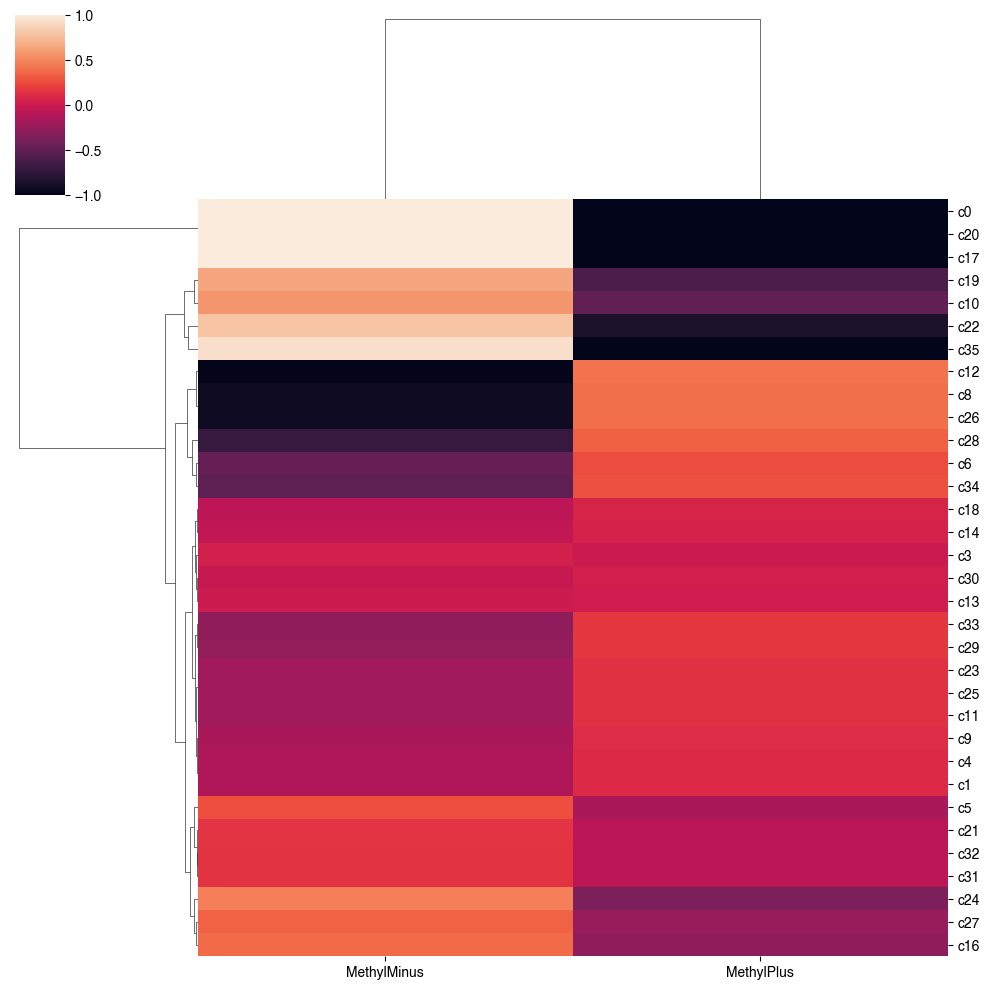

In [37]:
count = count.loc[['MethylMinus', 'MethylPlus']]
count = count.loc[:, count.sum(axis=0)>0]
motif_mc_dict = motif_mc_dict.loc[motif_mc_dict.isin(['MethylMinus', 'MethylPlus'])]
o2e = (count / count.sum(axis=0)).T / motif_mc_dict.value_counts() * motif_mc_dict.shape[0]
sns.clustermap(np.log2(o2e+0.01), vmin=-1, vmax=1)


## AME HOCOMOCO

In [38]:
# [pipeline/shell command — commented out; output is cached on disk]
# for ct in $(ls -d c*); do (
# bedtools getfasta -fi /large_storage/zhoulab/ref/hg38/fasta/hg38.fa -fo ${ct}/bed/hypo/${ct}.fa -bed ${ct}/bed/hypo/${ct}.bed
# bedtools getfasta -fi /large_storage/zhoulab/ref/hg38/fasta/hg38.fa -fo ${ct}/bed/hyper/${ct}.fa -bed ${ct}/bed/hyper/${ct}.bed
# ame --control ${ct}/bed/hyper/${ct}.fa --o ${ct}/out_hypo ${ct}/bed/hypo/${ct}.fa /large_storage/zhoulab/ref/motif_databases/HUMAN/HOCOMOCOv11_core_HUMAN_mono_meme_format.meme
# ame --control ${ct}/bed/hypo/${ct}.fa --o ${ct}/out_hyper ${ct}/bed/hyper/${ct}.fa /large_storage/zhoulab/ref/motif_databases/HUMAN/HOCOMOCOv11_core_HUMAN_mono_meme_format.meme
# ) & 
# done



In [39]:
# [pipeline/shell command — commented out; output is cached on disk]
# indir=/large_storage/zhoulab/zhoujt/project/ENTEx/analysis
# for ct in $(ls -d c*); do (
# bedtools getfasta -fi /large_storage/zhoulab/ref/hg38/fasta/hg38.fa -fo ${ct}/bed/${ct}.fa -bed ${indir}/loop_peak_motif/${ct}/merge_peak.slop1kb.bed
# ame --control ${ct}/bed/${ct}.fa --o ${ct}/out_hyper_all ${ct}/bed/hyper/${ct}.fa /large_storage/zhoulab/ref/motif_databases/HUMAN/HOCOMOCOv11_core_HUMAN_mono_meme_format.meme
# ame --control ${ct}/bed/${ct}.fa --o ${ct}/out_hypo_all ${ct}/bed/hypo/${ct}.fa /large_storage/zhoulab/ref/motif_databases/HUMAN/HOCOMOCOv11_core_HUMAN_mono_meme_format.meme
# ) & 
# done



In [40]:
motif_list = pd.read_csv(f'{outdir}HOCOMOCOv11_core_motif_list.txt', index_col=0, header=None).index
motif_list = motif_list.str.split(' ').str[1].str.split('_').str[0]
motif_list

Index(['AHR', 'AIRE', 'ALX1', 'ANDR', 'AP2A', 'AP2B', 'AP2C', 'ARI5B', 'ARNT',
       'ASCL1',
       ...
       'ZN768', 'ZN770', 'ZN816', 'ZNF18', 'ZNF41', 'ZNF76', 'ZNF85', 'ZNF8',
       'ZSC22', 'ZSC31'],
      dtype='object', name=0, length=401)

In [41]:
motif_mc_annot = pd.read_csv(f'{REF_ROOT}/yin_2017_motif_type.csv', header=0, index_col=0)
motif_mc_annot = motif_mc_annot.loc[~motif_mc_annot.index.isna()]
motif_mc_annot['Call'] = motif_mc_annot['Call'].map(callmap)
motif_mc_annot = motif_mc_annot.loc[motif_mc_annot.index.isin(motif_list)]
motif_mc_dict = pd.Series('no info', index=motif_list.unique())
motif_mc_dict.loc[motif_mc_annot.index] = motif_mc_annot['Call'].copy()


In [42]:
count = {}
pv = {}
for ct in L1_meta.index:
    file_path = f'{outdir}{ct}/out_hypo/ame.tsv'
    if not os.path.isfile(file_path):
        continue
    try:
        tmp = pd.read_csv(file_path, sep='\t', comment='#')
    except pd.errors.EmptyDataError:
        print(f'{ct} empty')
        continue
    tmp['gene_name'] = tmp['motif_ID'].str.split('_').str[0]
    tmp = tmp.loc[tmp['gene_name'].isin(motif_mc_dict.index) & (tmp['adj_p-value']<1e-2)]
    count[ct] = tmp['gene_name'].map(motif_mc_dict).value_counts()
    pv[ct] = tmp.set_index('motif_ID')['adj_p-value']

count = pd.DataFrame(count).fillna(0)
pv = pd.DataFrame(pv).fillna(1)


In [45]:
motif_mc_dict.value_counts()

no info          325
MethylMinus       36
MethylPlus        29
Little effect     11
Name: count, dtype: int64

In [46]:
count

,c33,c3,c22,c9,c20,c25,c30,c13,c8,c4,...,c0,c27,c1,c15,c26,c5,c10,c16,c21,c12
gene_name,,,,,,,,,,,,,,,,,,,,,
Little effect,6,9,6,10,10,6,6,10,10,7,...,9,6,6,6,8,8,10,7,6,9
MethylMinus,14,24,12,21,18,8,9,21,24,21,...,23,11,15,20,21,16,18,18,14,23
MethylPlus,5,6,5,6,6,5,5,8,8,5,...,7,5,5,5,6,6,7,7,5,6
no info,49,92,52,87,102,60,41,109,117,92,...,95,44,65,70,84,83,106,80,67,91


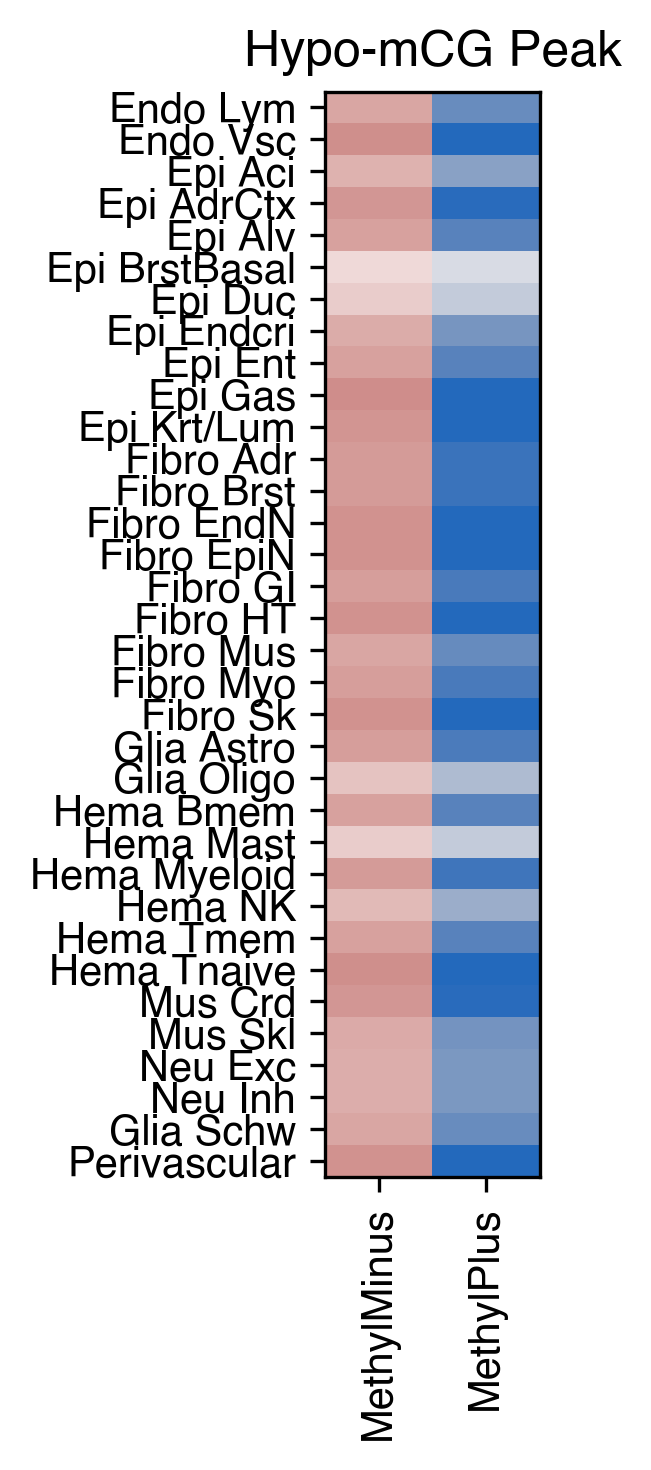

In [47]:
count = count.loc[['MethylMinus', 'MethylPlus']]
motif_mc_dict = motif_mc_dict.loc[motif_mc_dict.isin(['MethylMinus', 'MethylPlus'])]
o2e = (count / count.sum(axis=0)).T / motif_mc_dict.value_counts() * motif_mc_dict.shape[0]
# sns.clustermap(np.log2(o2e+0.01), vmin=-1, vmax=1, cmap='vlag')
fig, ax = plt.subplots(figsize=(2,5), dpi=300)
ax.imshow(np.log2(o2e+0.01), vmin=-1, vmax=1, cmap='vlag', aspect='auto')
ax.set_yticks(np.arange(o2e.shape[0]))
ax.set_yticklabels(o2e.index.map(L1_annot))
ax.set_xticks([0,1])
ax.set_xticklabels(o2e.columns, rotation=90)
ax.set_title('Hypo-mCG Peak')
fig.tight_layout()
fig.savefig(f'{outdir}hypo_motif.pdf', dpi=300)


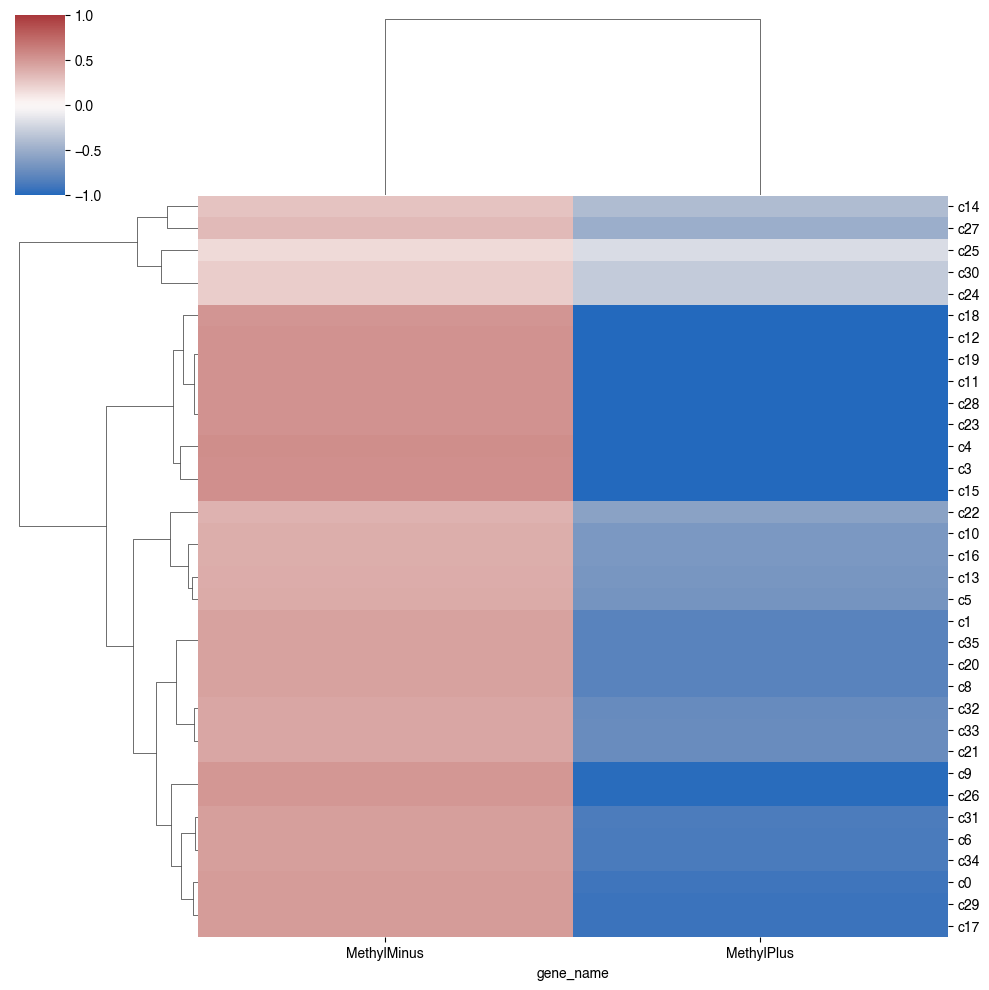

In [48]:
count = count.loc[['MethylMinus', 'MethylPlus']]
motif_mc_dict = motif_mc_dict.loc[motif_mc_dict.isin(['MethylMinus', 'MethylPlus'])]
o2e = (count / count.sum(axis=0)).T / motif_mc_dict.value_counts() * motif_mc_dict.shape[0]
sns.clustermap(np.log2(o2e+0.01), vmin=-1, vmax=1, cmap='vlag')


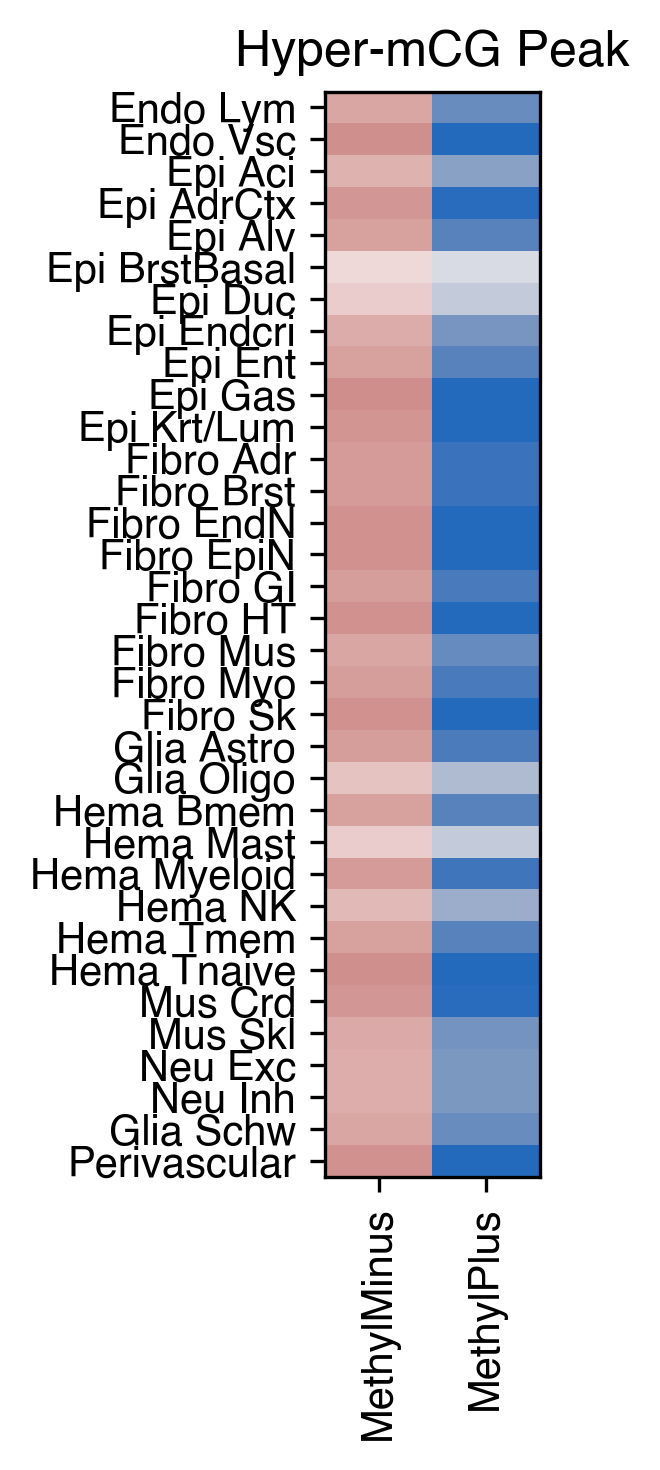

In [49]:
count = count.loc[['MethylMinus', 'MethylPlus']]
motif_mc_dict = motif_mc_dict.loc[motif_mc_dict.isin(['MethylMinus', 'MethylPlus'])]
o2e = (count / count.sum(axis=0)).T / motif_mc_dict.value_counts() * motif_mc_dict.shape[0]
# sns.clustermap(np.log2(o2e+0.01), vmin=-1, vmax=1, cmap='vlag')
fig, ax = plt.subplots(figsize=(2,5), dpi=300)
ax.imshow(np.log2(o2e+0.01), vmin=-1, vmax=1, cmap='vlag', aspect='auto')
ax.set_yticks(np.arange(o2e.shape[0]))
ax.set_yticklabels(o2e.index.map(L1_annot))
ax.set_xticks([0,1])
ax.set_xticklabels(o2e.columns, rotation=90)
ax.set_title('Hyper-mCG Peak')
fig.tight_layout()
fig.savefig(f'{outdir}hyper_motif.pdf', dpi=300)
